# Neural Graph Collaborative Filtering (NGCF)

## Objective

In this notebook, we implement **Neural Graph Collaborative Filtering (NGCF)** proposed in:

> Neural Graph Collaborative Filtering (SIGIR 2019)

Unlike traditional collaborative filtering models, NGCF models the user-item interaction graph using Graph Neural Networks (GNNs).

Key concepts:

- User-Item Bipartite Graph
- Message Passing
- Feature Transformation
- Bi-Interaction
- Graph Propagation
- Bayesian Personalized Ranking (BPR)

Notebook Outline

1. Data Loading
2. Data Preprocessing
3. Interaction Graph Construction
4. Graph Normalization
5. NGCF Architecture
6. BPR Training
7. Evaluation
8. Model Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
NUM_USERS = ratings["user_id"].nunique()

NUM_ITEMS = ratings["movie_id"].nunique()

print("Users :", NUM_USERS)

print("Items :", NUM_ITEMS)

print("Ratings :", len(ratings))

Users : 943
Items : 1682
Ratings : 100000


In [4]:
ratings["label"] = (

    ratings["rating"] >= 4

).astype(np.float32)

ratings.head()

,user_id,movie_id,rating,timestamp,label
0,195,241,3,881250949,0.0
1,185,301,3,891717742,0.0
2,21,376,1,878887116,0.0
3,243,50,2,880606923,0.0
4,165,345,1,886397596,0.0


In [5]:
train_df, test_df = train_test_split(

    ratings,

    test_size=0.2,

    random_state=42,

    stratify=ratings["label"]

)

print(train_df.shape)

print(test_df.shape)

(80000, 5)
(20000, 5)


In [6]:
interaction_matrix = sp.coo_matrix(

    (

        np.ones(len(train_df)),

        (

            train_df["user_id"],

            train_df["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_ITEMS

    )

)

interaction_matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 80000 stored elements and shape (943, 1682)>

In [7]:
num_nodes = NUM_USERS + NUM_ITEMS

adjacency_matrix = sp.dok_matrix(

    (

        num_nodes,

        num_nodes

    ),

    dtype=np.float32

)

adjacency_matrix = adjacency_matrix.tolil()

adjacency_matrix[

    :NUM_USERS,

    NUM_USERS:

] = interaction_matrix

adjacency_matrix[

    NUM_USERS:,

    :NUM_USERS

] = interaction_matrix.T

adjacency_matrix = adjacency_matrix.tocsr()

adjacency_matrix

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 160000 stored elements and shape (2625, 2625)>

In [8]:
degree = np.array(

    adjacency_matrix.sum(axis=1)

).flatten()

degree_inv_sqrt = np.power(

    degree,

    -0.5

)

degree_inv_sqrt[

    np.isinf(degree_inv_sqrt)

] = 0

D_inv = sp.diags(

    degree_inv_sqrt

)

normalized_graph = (

    D_inv

    @

    adjacency_matrix

    @

    D_inv

)

normalized_graph

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 160000 stored elements and shape (2625, 2625)>

In [9]:
normalized_graph = normalized_graph.tocoo()

indices = torch.LongTensor(

    np.vstack(

        (

            normalized_graph.row,

            normalized_graph.col

        )

    )

)

values = torch.FloatTensor(

    normalized_graph.data

)

graph = torch.sparse_coo_tensor(

    indices,

    values,

    normalized_graph.shape

)

graph = graph.coalesce()

graph

tensor(indices=tensor([[   0,    0,    0,  ..., 2618, 2620, 2624],
                       [ 943,  944,  945,  ...,  850,  862,  915]]),
       values=tensor([0.0036, 0.0068, 0.0083,  ..., 0.0776, 0.1104, 0.0645]),
       size=(2625, 2625), nnz=160000, layout=torch.sparse_coo)

In [10]:
print(graph.shape)

print(graph._nnz())

torch.Size([2625, 2625])
160000


In [11]:
class BPRDataset(Dataset):

    def __init__(

        self,

        ratings,

        num_items

    ):

        self.users = ratings["user_id"].values

        self.pos_items = ratings["movie_id"].values

        self.num_items = num_items

        self.user_history = (

            ratings.groupby(

                "user_id"

            )["movie_id"]

            .apply(set)

            .to_dict()

        )

    def __len__(self):

        return len(

            self.users

        )

    def __getitem__(

        self,

        idx

    ):

        user = self.users[idx]

        pos_item = self.pos_items[idx]

        while True:

            neg_item = np.random.randint(

                self.num_items

            )

            if neg_item not in self.user_history[user]:

                break

        return (

            torch.LongTensor([user]).squeeze(),

            torch.LongTensor([pos_item]).squeeze(),

            torch.LongTensor([neg_item]).squeeze()

        )

In [12]:
train_dataset = BPRDataset(

    train_df,

    NUM_ITEMS

)

train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True

)

In [13]:
batch = next(

    iter(train_loader)

)

for tensor in batch:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


In [14]:
class NGCFLayer(nn.Module):

    def __init__(

        self,

        embedding_dim

    ):

        super().__init__()

        self.linear_message = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        self.linear_bi = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        self.activation = nn.LeakyReLU(

            negative_slope=0.2

        )

    def forward(

        self,

        graph,

        embeddings

    ):

        neighbor_embeddings = torch.sparse.mm(

            graph,

            embeddings

        )

        sum_embeddings = self.linear_message(

            neighbor_embeddings

        )

        bi_embeddings = self.linear_bi(

            embeddings *

            neighbor_embeddings

        )

        embeddings = (

            sum_embeddings

            +

            bi_embeddings

        )

        embeddings = self.activation(

            embeddings

        )

        embeddings = F.normalize(

            embeddings,

            p=2,

            dim=1

        )

        return embeddings

In [15]:
layer = NGCFLayer(

    embedding_dim=64

)

dummy_embeddings = torch.randn(

    NUM_USERS + NUM_ITEMS,

    64

)

output = layer(

    graph,

    dummy_embeddings

)

print(output.shape)

torch.Size([2625, 64])


In [16]:
class NGCF(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        graph,

        embedding_dim=64,

        num_layers=3

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.graph = graph

        self.embedding_dim = embedding_dim

        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.item_embedding = nn.Embedding(

            num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.user_embedding.weight

        )

        nn.init.xavier_uniform_(

            self.item_embedding.weight

        )

        self.layers = nn.ModuleList(

            [

                NGCFLayer(

                    embedding_dim

                )

                for _ in range(

                    num_layers

                )

            ]

        )
    def get_initial_embeddings(

        self

    ):

        return torch.cat(

            [

                self.user_embedding.weight,

                self.item_embedding.weight

            ],

            dim=0

        )
        
    def propagate(

        self

    ):

        embeddings = self.get_initial_embeddings()

        all_embeddings = [

            embeddings

        ]

        for layer in self.layers:

            embeddings = layer(

                self.graph,

                embeddings

            )

            all_embeddings.append(

                embeddings

            )

        final_embeddings = torch.cat(

            all_embeddings,

            dim=1

        )

        return final_embeddings
    
    def get_embeddings(

        self

    ):

        embeddings = self.propagate()

        user_embeddings = embeddings[

            :self.num_users

        ]

        item_embeddings = embeddings[

            self.num_users:

        ]

        return (

            user_embeddings,

            item_embeddings

        )

    def forward(

        self,

        users,

        pos_items,

        neg_items

    ):

        user_embeddings, item_embeddings = self.get_embeddings()

        users = user_embeddings[

            users

        ]

        positives = item_embeddings[

            pos_items

        ]

        negatives = item_embeddings[

            neg_items

        ]

        pos_scores = (

            users *

            positives

        ).sum(dim=1)

        neg_scores = (

            users *

            negatives

        ).sum(dim=1)

        return (

            pos_scores,

            neg_scores

        )

In [17]:
model = NGCF(

    num_users=NUM_USERS,

    num_items=NUM_ITEMS,

    graph=graph,

    embedding_dim=64,

    num_layers=3

)

model

NGCF(
  (user_embedding): Embedding(943, 64)
  (item_embedding): Embedding(1682, 64)
  (layers): ModuleList(
    (0-2): 3 x NGCFLayer(
      (linear_message): Linear(in_features=64, out_features=64, bias=True)
      (linear_bi): Linear(in_features=64, out_features=64, bias=True)
      (activation): LeakyReLU(negative_slope=0.2)
    )
  )
)

In [18]:
batch = next(

    iter(train_loader)

)

users, pos, neg = batch

pos_scores, neg_scores = model(

    users,

    pos,

    neg

)

print(

    pos_scores.shape

)

print(

    neg_scores.shape

)

torch.Size([1024])
torch.Size([1024])


In [19]:
def bpr_loss(

    pos_scores,

    neg_scores

):

    loss = -torch.mean(

        F.logsigmoid(

            pos_scores -

            neg_scores

        )

    )

    return loss

In [20]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

In [21]:
def train_model(

    model,

    train_loader,

    optimizer,

    epochs=30

):

    history = []

    print("Training NGCF...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for (

            users,

            pos_items,

            neg_items

        ) in train_loader:

            optimizer.zero_grad()

            pos_scores, neg_scores = model(

                users,

                pos_items,

                neg_items

            )

            loss = bpr_loss(

                pos_scores,

                neg_scores

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [22]:
history = train_model(

    model,

    train_loader,

    optimizer,

    epochs=30

)

Training NGCF...
Epoch  1/30 | Loss = 0.4426
Epoch  2/30 | Loss = 0.3500
Epoch  3/30 | Loss = 0.3106
Epoch  4/30 | Loss = 0.2970
Epoch  5/30 | Loss = 0.2797
Epoch  6/30 | Loss = 0.2618
Epoch  7/30 | Loss = 0.2537
Epoch  8/30 | Loss = 0.2510
Epoch  9/30 | Loss = 0.2481
Epoch 10/30 | Loss = 0.2443
Epoch 11/30 | Loss = 0.2378
Epoch 12/30 | Loss = 0.2364
Epoch 13/30 | Loss = 0.2355
Epoch 14/30 | Loss = 0.2325
Epoch 15/30 | Loss = 0.2316
Epoch 16/30 | Loss = 0.2316
Epoch 17/30 | Loss = 0.2284
Epoch 18/30 | Loss = 0.2281
Epoch 19/30 | Loss = 0.2293
Epoch 20/30 | Loss = 0.2282
Epoch 21/30 | Loss = 0.2235
Epoch 22/30 | Loss = 0.2249
Epoch 23/30 | Loss = 0.2264
Epoch 24/30 | Loss = 0.2230
Epoch 25/30 | Loss = 0.2252
Epoch 26/30 | Loss = 0.2243
Epoch 27/30 | Loss = 0.2235
Epoch 28/30 | Loss = 0.2229
Epoch 29/30 | Loss = 0.2223
Epoch 30/30 | Loss = 0.2211


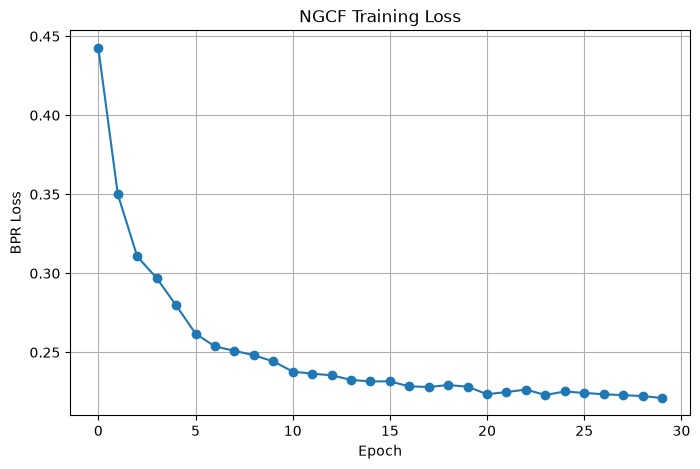

In [23]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.title("NGCF Training Loss")

plt.xlabel("Epoch")

plt.ylabel("BPR Loss")

plt.grid(True)

plt.show()

In [24]:
def recommend(

    model,

    user_id,

    top_k=10

):

    model.eval()

    with torch.no_grad():

        user_embeddings, item_embeddings = model.get_embeddings()

        user_vector = user_embeddings[user_id]

        scores = torch.matmul(

            item_embeddings,

            user_vector

        )

        _, indices = torch.topk(

            scores,

            top_k

        )

    return indices.cpu().numpy()

In [25]:
recommend(

    model,

    user_id=0,

    top_k=10

)

array([172, 152, 167, 171,  55, 203,   0, 108, 150, 234])

In [26]:
model.eval()

with torch.no_grad():

    user_embeddings, item_embeddings = model.get_embeddings()

prediction_df = test_df.copy()

scores = []

for row in prediction_df.itertuples():

    score = torch.dot(

        user_embeddings[row.user_id],

        item_embeddings[row.movie_id]

    ).item()

    scores.append(score)

prediction_df["score"] = scores
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

prediction_df["prediction"] = (

    prediction_df["probability"] >= 0.5

).astype(int)

In [27]:
accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(f"Accuracy : {accuracy:.4f}")

print(f"AUC : {auc:.4f}")

Accuracy : 0.5792
AUC : 0.6168


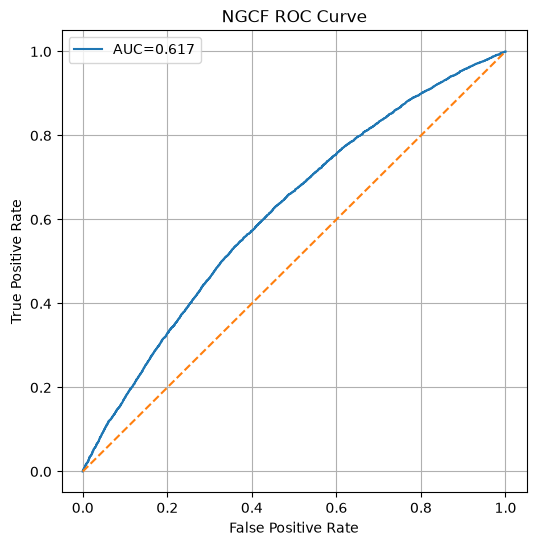

In [28]:
fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("NGCF ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )
    
    
    
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )
    
    
    
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [30]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

In [31]:
metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.579200
1,AUC,0.616769
2,Precision@10,0.629044
3,Recall@10,0.698481
4,HitRate@10,0.976670


In [32]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
70309,406,152,1.0,0.953888,1
14503,241,290,0.0,0.565402,1
22229,329,237,1.0,0.824765,1
34450,403,753,0.0,0.909158,1
28502,325,43,0.0,0.571354,1
78501,758,983,0.0,0.636690,1
62828,842,541,0.0,0.593104,1
85723,549,14,1.0,0.834114,1
99463,775,216,1.0,0.701197,1
95612,641,451,0.0,0.603017,1


In [33]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN v1",

            "DCN v2",

            "LightGCN",

            "NGCF"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            0.6681,

            0.6820,

            0.4803,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            0.7317,

            0.7406,

            0.5924,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            0.6480,

            0.6485,

            0.6792,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            0.7142,

            0.7138,

            0.2221,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            0.9756,

            0.9777,

            0.9979,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667


In [34]:
for metric in [

    "Accuracy",

    "AUC",

    "Precision@10",

    "Recall@10",

    "HitRate@10"

]:

    print(f"Best {metric}")

    display(

        comparison.sort_values(

            metric,

            ascending=False

        )

    )

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.99790
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
7,NGCF,0.5792,0.616769,0.629044,0.698481,0.97667
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.97560


# Conclusion

In this notebook, we implemented **Neural Graph Collaborative Filtering (NGCF)**, one of the first Graph Neural Network models designed specifically for recommendation systems.

Key observations:

- NGCF propagates information over the user-item interaction graph using message passing.
- Unlike LightGCN, NGCF applies feature transformation, bi-interaction modeling, nonlinear activation, and embedding normalization at every propagation layer.
- Final user and item representations are obtained by concatenating embeddings from all graph convolution layers.
- The model is trained using Bayesian Personalized Ranking (BPR), optimizing the relative ranking between positive and negative items.
- NGCF introduced graph neural networks into collaborative filtering and served as the foundation for many later graph-based recommendation models.

Although LightGCN later demonstrated that several NGCF components could be removed while maintaining or improving performance, NGCF remains a landmark architecture because it established the message-passing paradigm for recommendation systems.